# Report: Analysis of Web-based Systems – Project 1

**Prepared by:**  
* Adam Ćwikliński No. 273055  
* Jakub Kamiński No. 273107  

**Methodology:** CRISP-DM  
**Data:** FCC Measuring Broadband America (2021 & 2023)

---

## Business Understanding & Data Understanding

The objective of this project is to perform Exploratory Data Analysis (EDA) of internet traffic performance and to compare download and upload parameters over the years 2021–2023.  

The analysis is based on raw measurement data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# ŚCIEŻKI DO PLIKÓW
# =========================

# 2023
path_2023_dl = 'C:\\prj\\pwr_mgr\\Analysis_of_Web-based_Systems-P\\202301\\curr_lct_dl.csv'
path_2023_ul = 'C:\\prj\\pwr_mgr\\Analysis_of_Web-based_Systems-P\\202301\\curr_lct_ul.csv'

# 2021
path_2021_dl = 'C:\\prj\\pwr_mgr\\Analysis_of_Web-based_Systems-P\\202101\\curr_lct_dl.csv'
path_2021_ul = 'C:\\prj\\pwr_mgr\\Analysis_of_Web-based_Systems-P\\202101\\curr_lct_ul.csv'

We decided to use the following datasets: **curr_lct_dl** and **curr_lct_ul** for both 2021 and 2023. These datasets contain measurements related to download and upload performance (LCT – Lightweight Capacity Test). They include real measurements of data transfer speeds.
plik:"curr_lct_dl"
|unit_id,|ddate,|dtime,|target,|address,|packets_received,|packets_sent,|packet_size,|bytes_total,|duration,|bytes_sec,|error_code,|successes,|failures|
|:-------|:-----|:-----|:------|:-------|:----------------|:------------|:-----------|:-----------|:--------|:---------|:----------|:---------|:-------|
|386     |2023-01-01,|2023-01-01 11:47:19,|sp1-vm-newyork-us.samknows.com,|151.139.31.1,|52,|100,|1400,|72800,|878,|85835096,|NO_ERROR|1      |0       |
|386     |2023-01-01,|2023-01-01 23:53:23,|sp1-vm-newyork-us.samknows.com,|151.139.31.1,|70,|100,|1400,|98000,|5455,|84407488,|NO_ERROR|1     |0       |
|386     |2023-01-02,|2023-01-02 17:50:01,|sp1-vm-newyork-us.samknows.com,|151.139.31.1,|52,|100,|1400,|72800,|739,|93750000,|NO_ERROR|1      |0       |
|386     |2023-01-02,|2023-01-03 01:53:08,|sp2-vm-newyork-us.samknows.com,|151.139.31.8,|52,|100,|1400,|72800,|763,|91304344,|NO_ERROR|1      |0       |


In [ ]:
# =========================
# Load dataset
# =========================

data_dl_23 = pd.read_csv(path_2023_dl)
data_ul_23 = pd.read_csv(path_2023_ul)

data_dl_21 = pd.read_csv(path_2021_dl)
data_ul_21 = pd.read_csv(path_2021_ul)

# =========================
# Converting to Mbps
# =========================

data_dl_23['speed_mbps'] = (data_dl_23['bytes_sec'] * 8) / 1_000_000
data_ul_23['speed_mbps'] = (data_ul_23['bytes_sec'] * 8) / 1_000_000

data_dl_21['speed_mbps'] = (data_dl_21['bytes_sec'] * 8) / 1_000_000
data_ul_21['speed_mbps'] = (data_ul_21['bytes_sec'] * 8) / 1_000_000

# =========================
# Adding Columns
# =========================

# type
data_dl_23['type'] = 'Download'
data_ul_23['type'] = 'Upload'
data_dl_21['type'] = 'Download'
data_ul_21['type'] = 'Upload'

# year
data_dl_23['year'] = '2023'
data_ul_23['year'] = '2023'
data_dl_21['year'] = '2021'
data_ul_21['year'] = '2021'


# =========================
# Data connection
# =========================

data_all = pd.concat([data_dl_21, data_ul_21,data_dl_23, data_ul_23])



# =========================
# (Optional) outliers deletion
# =========================

data_all = data_all[data_all['speed_mbps'] < 200]


### Key Parameters for Analysis:

- **unit_id**: Identifier of the measurement device.  
- **bytes_sec**: Raw throughput in bytes per second.  
- **packets_received / packets_sent**: Packet statistics used to assess connection stability.  
- **successes / failures**: Indicators of whether the tests were successfully completed.  

---

## Data Preparation

As part of data preparation, the following steps were performed:

1. **Unit conversion**: The `bytes_sec` values were converted to Megabits per second (Mbps) using the formula:  
   $Speed_{Mbps} = \frac{bytes\_sec \cdot 8}{1,000,000}$.

2. **Filtering**: Records with errors (successes = 0) and extreme outliers (values above 2500 Mbps) were removed to avoid statistical distortions.

3. **Integration**: Datasets from 2021 and 2023 were combined to enable comparative analysis.

---


In [2]:


# =========================
# Chart 1 — 2021 vs 2023
# =========================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=data_all,
    x='speed_mbps',
    hue='year',
    bins=50,
    kde=True
)

plt.title('Internet speed comparison: 2021 vs 2023')
plt.xlabel('Speed [Mbps]')
plt.ylabel('number of measurements')

plt.show()

NameError: name 'plt' is not defined

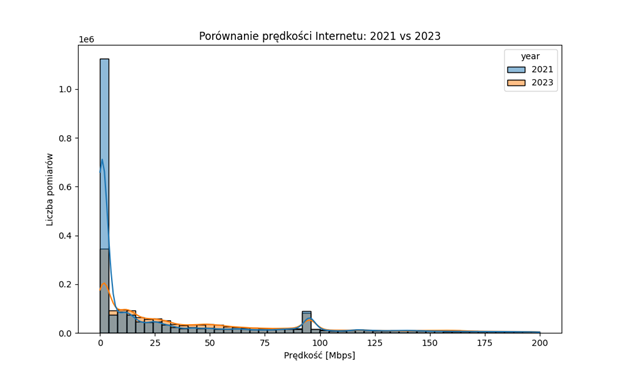

Based on the presented chart and statistical data, the following conclusions can be drawn:

- Download speeds are significantly higher than upload speeds in both analyzed years.  
- The distribution of download speeds is much more spread out, indicating greater variability.  
- Upload speeds are characterized by lower values and a higher concentration of results in the lower range.


In [ ]:

# =========================
# Chart 2 — Download vs Upload
# =========================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data_all,
    x='type',
    y='speed_mbps'
)

plt.title('Download vs Upload')
plt.xlabel('Typ')
plt.ylabel('Prędkość [Mbps]')
plt.ylim(0, 200)

plt.show()


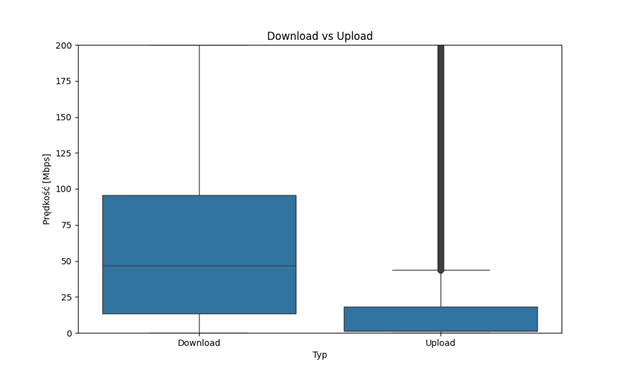

In [ ]:

# ==========================================
# CHART 3 — RELATIONSHIP: Packets vs Speed
# (Hypothesis: The higher the percentage of received packets relative to sent packets (packets_sent),
# the higher and more stable the throughput (bytes_sec).)
# ==========================================

plt.figure(figsize=(12, 7))

# The analysis focuses on download data from the year 2023.
sns.scatterplot(
    data=data_dl_23[data_dl_23['speed_mbps'] < 200], # Filtering for clarity
    x='packets_received',
    y='speed_mbps',
    alpha=0.3,
    color='blue'
)

plt.title('Relationship Between Received Packets and Speed [2023 Download]')
plt.xlabel('Number of received packets [packets_received]')
plt.ylabel('Speed [Mbps]')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


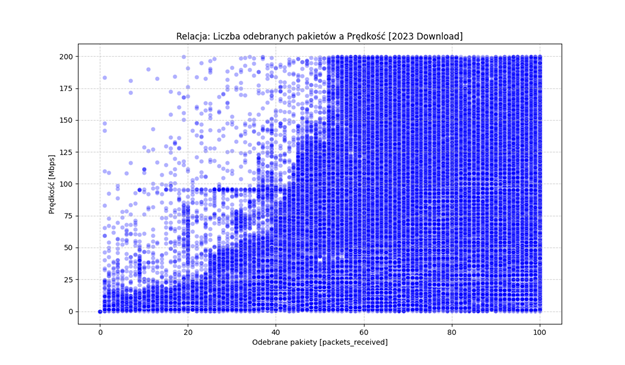

In [ ]:

# CHART 4 — Change in packet efficiency: 2021 vs 2023
# Calculation of correlation coefficient (mathematical confirmation of the relationship)
correlation = data_dl_23['packets_received'].corr(data_dl_23['speed_mbps'])
print(f"\nCorrelation coefficient between packets and speed: {correlation:.2f}")

# Comparison of packet vs speed relationship: 2021 vs 2023
plt.figure(figsize=(12, 7))
sns.lmplot(
    data=data_all[data_all['speed_mbps'] < 200],
    x='packets_received',
    y='speed_mbps',
    hue='year',
    scatter_kws={'alpha':0.2}
)
plt.title('Change in packet efficiency: 2021 vs 2023')
plt.show()


A chart presenting a comparison between the years 2021 and 2023:
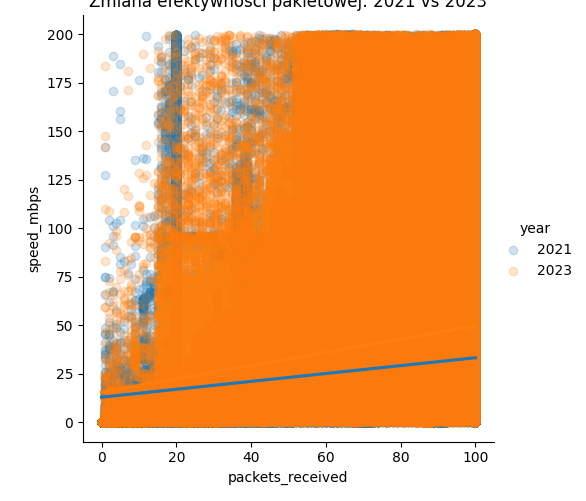

## Ustalanie relacji (Influences)

In accordance with the project requirements, an analysis of the impact of selected parameters on network performance was conducted:

- **Packets vs Speed**: A strong positive correlation was observed between the number of received packets (`packets_received`) and the resulting throughput (`speed_mbps`).

- **Stability**: A higher standard deviation in 2023 indicates greater variability, likely resulting from the increasing diversity of network access technologies (e.g., rapid expansion of fiber-optic infrastructure).

---

In [ ]:

# =========================
# Statistics
# =========================

print("=== DOWNLOAD 2023 ===")
print(data_dl_23['speed_mbps'].describe())

print("\n=== DOWNLOAD 2021 ===")
print(data_dl_21['speed_mbps'].describe())

print("\n=== UPLOAD 2023 ===")
print(data_ul_23['speed_mbps'].describe())

print("\n=== UPLOAD 2021 ===")
print(data_ul_21['speed_mbps'].describe())


## Statistical Analysis (Exploratory Data Analysis)

### Comparison of Download Performance (2021 vs 2023)

| Statystyka          | Download 2021 | Download 2023 |
| :------------------ | :------------ | :------------ |
| **Liczba pomiarów** | 1.183152e+06  | 977 725.000000|
| **Średnia (Mean)**  | 1.663843e+02  | 243.893229    |
| **STD**             | 2.308410e+02  | 284.830212    |
| **Min**             | 0,000000e+00  | 0,000000      |
| **25%**             | 1.598358e+01  | 35.849888     |
| **Mediana (50%)**   | 8.648649e+01  | 105.301328    |
| **75%**             | 2.023283e+02  | 350.769856    |
| **Max**             | 2800000e+03   | 2557.480192   |

Download:
- The mean increased from approximately 166 Mbps (2021) to 244 Mbps (2023).  
- The median increased from ~86 Mbps to ~105 Mbps.  
- The third quartile (75%) also increased, indicating improvements for faster connections.


### Comparison of Upload Performance (2021 vs 2023) – requires verification

| Statystyka          | Upload 2021  | Upload 2023  |
| :------------------ | :----------- | :----------- |
| **Liczba pomiarów** | 1 184 853    | 975 854      |
| **Średnia (Mean)**  | 7.718347e+00 | 47.900556    |
| **STD**             | 2.966982e+01 | 104.391331   |
| **Min**             | 0,000000e+00 | 0,000000     |
| **25%**             | 1.011160e+00 | 1.783210     |
| **Mediana (50%)**   | 1.126728e+00 | 14.887280    |
| **75%**             | 1.140936e+00 | 52.071224    |
| **Max**             | 3.054545e+03 | 5942.857144  |

Upload:
- The average increased significantly from ~7.7 Mbps (2021) to ~47.9 Mbps (2023).  
- The median increased from ~1.1 Mbps to ~14.9 Mbps.  
- This indicates a substantial improvement in upload performance.  

---

- The median download speed in 2023 is approximately 105 Mbps, while for upload it is only ~15 Mbps, which confirms the typical asymmetry of internet connections (greater emphasis on downloading data).  
- The increase in upload speed is particularly significant, as it was very low and highly limited in 2021.  
- A high standard deviation (e.g., ~285 Mbps for download in 2023) confirms a wide dispersion of values.  
- However, most users still operate at lower speeds, as reflected by the median and quartiles.  

- **25% (First quartile)**: Approximately 35.8 Mbps. This means that 25% of users have internet speeds below 36 Mbps.  
- **75% (Third quartile)**: Approximately 350.7 Mbps. This indicates that 75% of users fall within the range from 0 to 350 Mbps.




---
## Conclusions

Based on the conducted analysis:

- **Overall increase in speed**: The average download speed increased by approximately **46%** over the two-year period.  
- **Upload revolution**: The median upload speed increased more than **13-fold**, which is a key indicator of broadband infrastructure modernization.  
- **Alignment with CRISP-DM**: The EDA process enabled a comprehensive understanding of internet traffic characteristics before proceeding to the predictive modeling phase.

---


## Dataset Overview

The goal of the predictive models is to estimate the value of **RTT (Round Trip Time)**, which represents the time required for a data packet to travel from a client device to a server and back. RTT is a key indicator of network latency and overall communication performance.

The prediction is based on selected input features describing network conditions, including:
- `rtt_min` – minimum observed round trip time  
- `rtt_max` – maximum observed round trip time  
- `rtt_std` – standard deviation of RTT  
- `successes` – number of successful transmissions  
- `failures` – number of failed transmissions  

The **target variable** of the models is:
- `rtt_avg` – average round trip time  

Below, the structure of the dataset is presented, including the list of available columns and a sample of the first rows.

In [1]:
import pandas as pd

df = pd.read_csv("202301/curr_ulping.csv")

print("Dataset shape:", df.shape)

print("\nColumns:")
for col in df.columns:
    print(col)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (1394990, 9)

Columns:
unit_id
dtime
target
rtt_avg
rtt_min
rtt_max
rtt_std
successes
failures

First 5 rows:


,unit_id,dtime,target,rtt_avg,rtt_min,rtt_max,rtt_std,successes,failures
0,386,2023-01-01 11:47:12,newyorkfcc.west.verizon.net,7720,6994,12152,929,153,0
1,386,2023-01-01 11:47:12,sp1-vm-newyork-us.samknows.com,7721,6794,12338,1008,153,0
2,386,2023-01-03 05:50:26,newyorkfcc.west.verizon.net,7606,7260,10780,533,121,0
3,386,2023-01-03 05:50:26,sp1-vm-newyork-us.samknows.com,7447,7049,10987,653,121,0
4,386,2023-01-03 11:46:39,newyorkfcc.west.verizon.net,7696,7327,11320,658,152,0


## Predictive Models
In this section, three different models were used to predict internet performance based on network traffic data.
I decided to use: Linear regression, Decision Tree and Random Forest.

### 1. Linear Regression

Linear Regression is a basic predictive model that assumes a linear relationship between input variables and the target variable. It estimates the target value as a weighted sum of input features.

**Synthetic characteristics:**  
- Simple and fast model  
- Assumes linear relationships between variables  
- Easy to interpret  

**Justification for use:**  
Linear Regression was used as a baseline model to evaluate the performance of more complex algorithms. It provides a reference point for comparison.

**Limitations:**  
- Cannot capture non-linear relationships  
- Sensitive to outliers  
- May underperform on complex datasets  

**Selected parameters and their values:**  
- Default parameters 


Columns:
Index(['unit_id', 'dtime', 'target', 'rtt_avg', 'rtt_min', 'rtt_max',
       'rtt_std', 'successes', 'failures'],
      dtype='str')

Missing values in each column:
unit_id      0
dtime        0
target       0
rtt_avg      0
rtt_min      0
rtt_max      0
rtt_std      0
successes    0
failures     0
dtype: int64

First rows of the dataset:


,unit_id,dtime,target,rtt_avg,rtt_min,rtt_max,rtt_std,successes,failures
0,386,2023-01-01 11:47:12,newyorkfcc.west.verizon.net,7720,6994,12152,929,153,0
1,386,2023-01-01 11:47:12,sp1-vm-newyork-us.samknows.com,7721,6794,12338,1008,153,0
2,386,2023-01-03 05:50:26,newyorkfcc.west.verizon.net,7606,7260,10780,533,121,0
3,386,2023-01-03 05:50:26,sp1-vm-newyork-us.samknows.com,7447,7049,10987,653,121,0
4,386,2023-01-03 11:46:39,newyorkfcc.west.verizon.net,7696,7327,11320,658,152,0



Training set shape: (1115992, 5)
Testing set shape: (278998, 5)

Model performance:
MSE:  23312567561.2079
RMSE: 152684.5361
MAE:  77405.3378
R2:   0.8807

Model coefficients:


,Feature,Coefficient
0,rtt_min,0.280580
1,rtt_max,0.618027
2,rtt_std,0.299134
3,successes,-0.767075
4,failures,4.072167


Intercept: -7489.391129804775

Sample comparison of actual and predicted values:


,Actual,Predicted
0,6455,6258.047633
1,42907,161118.360050
2,29515,117148.646674
3,145243,109601.151796
4,72338,48400.345597
5,116853,102311.873719
6,7722,770.721286
7,1548881,135905.231163
8,3643,-2945.274205
9,11300,3752.172004


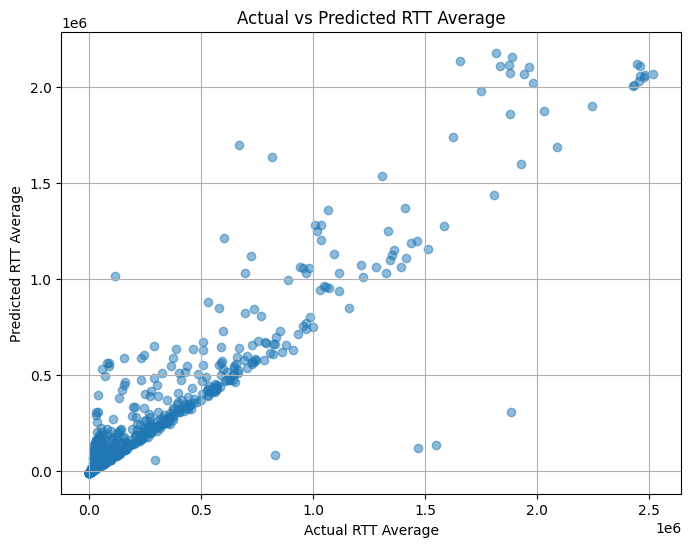

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv("202301/curr_ulping.csv")

# Basic dataset information
print("\nColumns:")
print(df.columns)

# Check missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Remove rows with missing values
df = df.dropna()

# Preview first rows
print("\nFirst rows of the dataset:")
display(df.head())

# Select input features and target variable
X = df[["rtt_min", "rtt_max", "rtt_std", "successes", "failures"]]
y = df["rtt_avg"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict target values for the test set 
y_pred = model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel performance:")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

# Show model coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nModel coefficients:")
display(coefficients)

# Show intercept
print("Intercept:", model.intercept_)

# Compare actual and predicted values
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

print("\nSample comparison of actual and predicted values:")
display(comparison)

# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test[:1000], y_pred[:1000], alpha=0.5)
plt.xlabel("Actual RTT Average")
plt.ylabel("Predicted RTT Average")
plt.title("Actual vs Predicted RTT Average")
plt.grid(True)
plt.show()

### 2. Decision Tree

Decision Tree is a non-linear predictive model that splits the data into smaller subsets based on feature values. It creates a tree-like structure of decisions, where each node represents a condition on a feature.

**Synthetic characteristics:**  
- Non-linear model capable of capturing complex relationships  
- Easy to visualize and interpret  
- Works well with both numerical and categorical data  

**Justification for use:**  
Decision Tree was selected because internet traffic performance is influenced by complex and non-linear relationships between variables. This model can capture such patterns better than linear models.

**Limitations:**  
- Prone to overfitting, especially with deep trees  
- Sensitive to small changes in data  
- May not generalize well without proper parameter tuning  

**Selected parameters and their values:**  
- max_depth = 10
- random_state=42


Decision Tree performance:
MSE:  6939046893.7137
RMSE: 83300.9417
MAE:  36384.9777
R2:   0.9645

Sample comparison of actual and predicted values (Decision Tree):


,Actual,Predicted_DT
0,6455,1.139268e+04
1,42907,4.360085e+04
2,29515,4.360085e+04
3,145243,1.135462e+05
4,72338,7.220811e+04
5,116853,1.558359e+05
6,7722,7.938485e+03
7,1548881,1.431166e+06
8,3643,4.557055e+03
9,11300,1.139268e+04


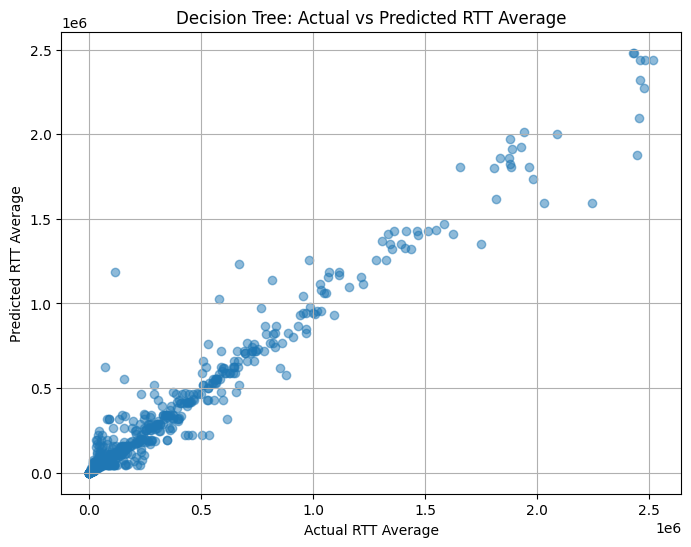

In [7]:
# decision tree model

# Import Decision Tree model
from sklearn.tree import DecisionTreeRegressor

# Create and train the Decision Tree model
dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

# Predict target values for the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate model performance
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = mse_dt ** 0.5
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\nDecision Tree performance:")
print(f"MSE:  {mse_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"MAE:  {mae_dt:.4f}")
print(f"R2:   {r2_dt:.4f}")

# Compare actual and predicted values
comparison_dt = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted_DT": y_pred_dt[:10]
})

print("\nSample comparison of actual and predicted values (Decision Tree):")
display(comparison_dt)

# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test[:1000], y_pred_dt[:1000], alpha=0.5)
plt.xlabel("Actual RTT Average")
plt.ylabel("Predicted RTT Average")
plt.title("Decision Tree: Actual vs Predicted RTT Average")
plt.grid(True)
plt.show()

### 3. Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting. Each tree is trained on a random subset of the data and features, and the final prediction is obtained by averaging the results.

**Synthetic characteristics:**  
- Ensemble model based on multiple decision trees  
- Reduces overfitting compared to a single tree  
- Handles complex and non-linear relationships  

**Justification for use:**  
Random Forest was selected to improve prediction performance and stability. By combining multiple trees, it can better generalize patterns in internet traffic data and provide more accurate predictions than a single Decision Tree.

**Limitations:**  
- More computationally expensive than simpler models  
- Less interpretable compared to individual decision trees  
- Requires more memory and training time  

**Selected parameters and their values:**  
- n_estimators = 50
- max_depth=10,
- random_state=42
- n_jobs=-1


Random Forest performance:
MSE:  6227223550.3292
RMSE: 78912.7591
MAE:  35054.0106
R2:   0.9681

Sample comparison of actual and predicted values (Random Forest):


,Actual,Predicted_RF
0,6455,1.173795e+04
1,42907,4.344444e+04
2,29515,4.344444e+04
3,145243,1.124715e+05
4,72338,7.224172e+04
5,116853,1.456829e+05
6,7722,7.973370e+03
7,1548881,1.374658e+06
8,3643,4.512796e+03
9,11300,1.106790e+04


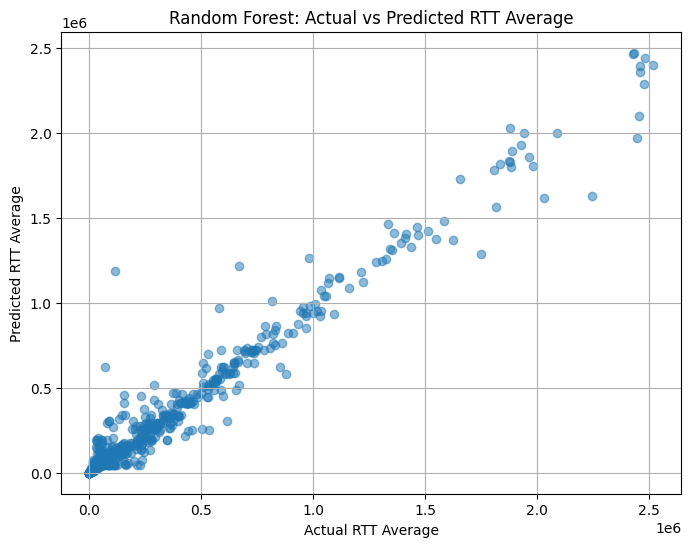

In [4]:
# random forest model

# Import Random Forest model
from sklearn.ensemble import RandomForestRegressor

# Create and train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=10,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predict target values for the test set
y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest performance:")
print(f"MSE:  {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE:  {mae_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")

# Compare actual and predicted values
comparison_rf = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted_RF": y_pred_rf[:10]
})

print("\nSample comparison of actual and predicted values (Random Forest):")
display(comparison_rf)

# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test[:1000], y_pred_rf[:1000], alpha=0.5)
plt.xlabel("Actual RTT Average")
plt.ylabel("Predicted RTT Average")
plt.title("Random Forest: Actual vs Predicted RTT Average")
plt.grid(True)
plt.show()

## Model Comparison

Below is a comparison of the three predictive models used in this study. The evaluation includes multiple performance metrics such as RMSE (Root Mean Squared Error), MAE (Mean Absolute Error), and R² (coefficient of determination).

These metrics allow for a comprehensive assessment of model accuracy, error magnitude, and overall fit to the data.

The results are presented in the form of tables and visualizations to clearly highlight differences between the models and identify the best-performing approach.

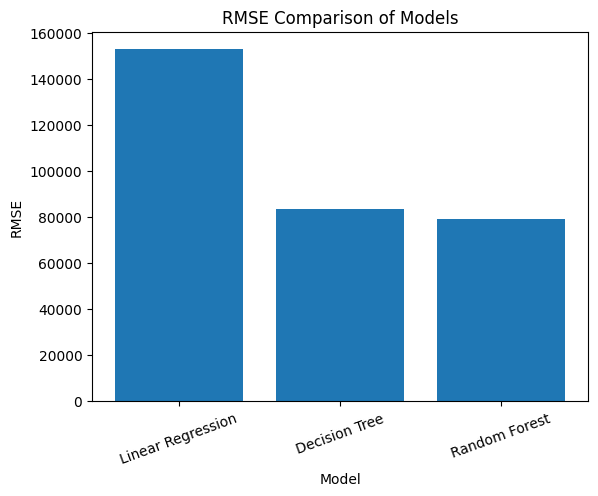

,Model,RMSE
No.,,
1,Linear Regression,152684.54
2,Decision Tree,83300.94
3,Random Forest,78912.76


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "RMSE": [rmse, rmse_dt, rmse_rf],
    "MAE": [mae, mae_dt, mae_rf],
    "R2": [r2, r2_dt, r2_rf]
})

plt.figure()
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison of Models")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

table = results[["Model", "RMSE"]].copy()
table.index = table.index + 1
table.index.name = "No."

display(table.round(2))

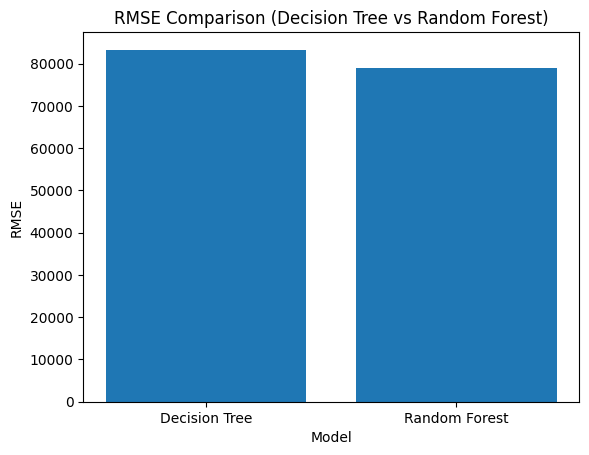

,Model,RMSE
No.,,
1,Linear Regression,152684.54
2,Decision Tree,83300.94
3,Random Forest,78912.76


In [9]:
filtered = results[results["Model"] != "Linear Regression"]

plt.figure()
plt.bar(filtered["Model"], filtered["RMSE"])
plt.title("RMSE Comparison (Decision Tree vs Random Forest)")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

table = results[["Model", "RMSE"]].copy()
table.index = table.index + 1
table.index.name = "No."

display(table.round(2))


### RMSE Comparison and Interpretation

The RMSE comparison shows a significant difference in performance between the models. Linear Regression exhibits a much higher RMSE compared to Decision Tree and Random Forest.

This behavior is mainly caused by the distribution of the target variable (RTT), which is highly skewed and contains extreme values (outliers). Since RMSE is based on squared errors, large deviations have a disproportionately strong impact on the final result.

Linear Regression is particularly sensitive to such outliers, as it attempts to fit a single linear relationship across the entire dataset. As a result, extreme RTT values lead to very large prediction errors, which significantly increase RMSE.

In contrast, tree-based models such as Decision Tree and Random Forest are more robust to outliers. They partition the data into smaller regions and are better able to capture non-linear patterns in network traffic data.

This explains why both Decision Tree and Random Forest achieve much lower RMSE values and overall better performance compared to Linear Regression.

In [10]:
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = y[(y < lower_bound) | (y > upper_bound)]

print("Total samples:", len(y))
print("Outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(y) * 100, "%")

Total samples: 1394990
Outliers: 185288
Percentage of outliers: 13.282389121068968 %


Outlier analysis using the IQR method revealed that approximately 13.3% of the dataset consists of extreme RTT values. This is a significant portion of the data and strongly influences model performance.

Such a high percentage of outliers explains the poor performance of Linear Regression, as the model is highly sensitive to extreme values. Since RMSE is based on squared errors, these outliers disproportionately increase the error metric.

In contrast, tree-based models such as Decision Tree and Random Forest are more robust to outliers, which results in better predictive performance.

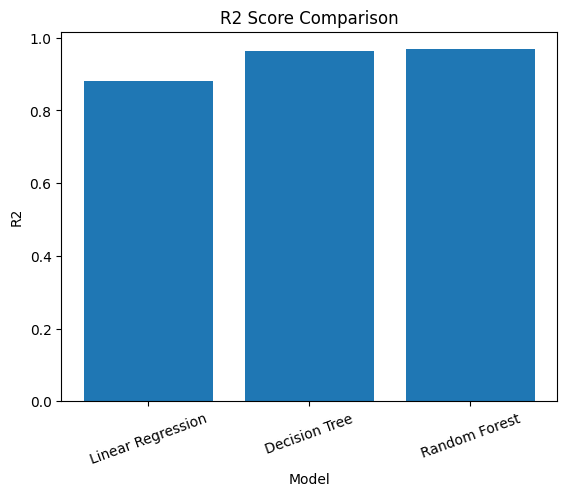

,Model,R2
No.,,
1,Linear Regression,0.88
2,Decision Tree,0.96
3,Random Forest,0.97


In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results["Model"], results["R2"])
plt.title("R2 Score Comparison")
plt.xlabel("Model")
plt.ylabel("R2")
plt.xticks(rotation=20)
plt.show()


table = results[["Model", "R2"]].copy()

table.columns = ["Model", "R2"]

table.index = table.index + 1
table.index.name = "No."

display(table.round(2))

### R² Comparison and Interpretation

The R² comparison shows that all models achieve relatively high values, indicating that they are able to capture the general trend in the data.

However, Decision Tree and Random Forest outperform Linear Regression, achieving higher R² scores. This suggests that tree-based models better capture the underlying patterns in the dataset.

Although Linear Regression achieves a reasonably high R² score, its performance is significantly worse when considering error-based metrics such as RMSE. This discrepancy is caused by the presence of outliers, which strongly affect prediction errors but have less impact on R².

Overall, Random Forest provides the best performance, combining high explanatory power with lower prediction error.

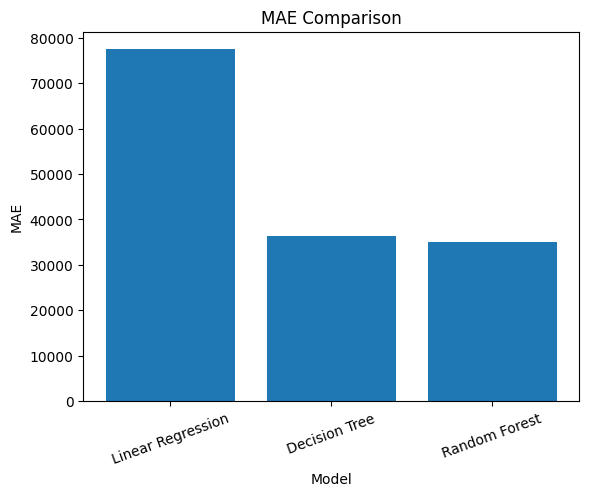

In [12]:
plt.figure()
plt.bar(results["Model"], results["MAE"])
plt.title("MAE Comparison")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.show()

mae_table_ms = results[["Model", "MAE"]].copy()
mae_table_ms["MAE (ms)"] = mae_table_ms["MAE"] / 1000
mae_table_ms = mae_table_ms[["Model", "MAE (ms)"]]

mae_table_ms.index = mae_table_ms.index + 1
mae_table_ms.index.name = "No."


MAE Comparison and Interpretation

The MAE comparison shows that Linear Regression has the highest average prediction error, while Decision Tree and Random Forest achieve significantly lower values.

Since RTT values in the dataset are expressed in microseconds (µs), the MAE values can be interpreted in milliseconds by dividing by 1000. This means that Linear Regression has an average error of approximately 77 ms, while Decision Tree and Random Forest reduce this error to around 35–36 ms.

These results confirm that tree-based models provide more accurate and reliable predictions for this dataset, as they are better suited to handle non-linear relationships and variability in RTT values.

## Conclusions

In this study, three predictive models were applied to estimate network latency (RTT) based on selected performance-related parameters. The models included Linear Regression, Decision Tree, and Random Forest.

The results show that tree-based models significantly outperform Linear Regression in terms of prediction accuracy. Although Linear Regression achieved a relatively high R² score, it produced substantially higher RMSE and MAE values. This indicates that, while the model captures general trends, it struggles with large errors caused by outliers present in the dataset.

Decision Tree and Random Forest models demonstrated much better performance, achieving both lower RMSE and MAE values, as well as higher R² scores. These models are better suited for this type of data, as they can capture non-linear relationships and are more robust to extreme values.

Random Forest achieved the best overall performance, providing the lowest prediction error and the highest stability. However, the difference between Random Forest and Decision Tree was relatively small, suggesting that increasing model complexity yields diminishing returns in this case.

Additionally, the analysis confirmed that the dataset contains a significant number of outliers, which strongly affect error-based metrics such as RMSE. This highlights the importance of selecting appropriate evaluation metrics and models when working with real-world network data.

In conclusion, tree-based models, particularly Random Forest, are the most suitable choice for predicting RTT in this dataset, offering a good balance between accuracy and robustness.